# Matrix Multiplication and Powers

**This notebook is self-contained; it recaps the dot product and matrix basics as needed.**

Matrix multiplication looks strange at first — it is *not* just multiplying matching entries. Instead, each entry of the product is a **dot product** of a row with a column. That rule is what lets a matrix transform vectors, chain transformations, and — through its **powers** — count paths in a network. This notebook builds the rule from the dot product and shows two payoffs: a real cost calculation and counting connections in a small social network.

## Learning objectives

- Compute a **matrix–vector** and **matrix–matrix** product using the row-by-column rule.
- See that matrix multiplication is **not commutative** ($AB \ne BA$).
- Interpret **powers** $A^n$ of a network's matrix as counts of $n$-step paths.

## Background

To multiply, each entry of the product is the **dot product** of a row of the first matrix with a column of the second:

$$(AB)_{ij} = \sum_k A_{ik} B_{kj}.$$

A matrix times a vector, $A\mathbf{x}$, can be read two ways: as these row-by-column dot products, or as a **combination of $A$'s columns**. Order matters: usually $AB \ne BA$. For a network whose matrix $A$ records direct links, the power $A^n$ counts the number of **$n$-step paths** between nodes.

## This notebook covers

1. Matrix times a vector.
2. Matrix times a matrix (the row-by-column rule).
3. Order matters ($AB \ne BA$).
4. An application: a cost calculation.
5. Powers as path counts in a network.

**Prerequisites:** `U2-3_Matrices-1_ArithmeticAndSpecial`, `U2-2_Vectors-2_DotProductAndAngle`

**Dataset:** none — small matrices and a tiny network entered inline.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# shared display helper (msds520_helpers.py lives at the MSDS 520 course root).
# notebooks sit two folders below it, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds520_helpers as helpers

## 1. Matrix times a vector

Each entry of $A\mathbf{x}$ is a row of $A$ dotted with $\mathbf{x}$:

$$\begin{bmatrix}1&2\\3&4\end{bmatrix}\begin{bmatrix}5\\6\end{bmatrix} = \begin{bmatrix}1\cdot5 + 2\cdot6\\ 3\cdot5 + 4\cdot6\end{bmatrix} = \begin{bmatrix}17\\39\end{bmatrix}.$$

You can also read the answer as a **combination of the columns**: $5\begin{bmatrix}1\\3\end{bmatrix} + 6\begin{bmatrix}2\\4\end{bmatrix}$.

In [2]:
A = np.array([[1, 2], [3, 4]])
x = np.array([5, 6])

helpers.show(A, name="A")
helpers.show(x, name=r"\mathbf{x}")
helpers.show(A @ x, name=r"A\mathbf{x}")
helpers.show(5 * A[:, 0] + 6 * A[:, 1], label="same answer, built from the columns")

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## 2. Matrix times a matrix

For a product of two matrices, entry $(i, j)$ is row $i$ of the first dotted with column $j$ of the second:

$$\begin{bmatrix}1&2\\3&4\end{bmatrix}\begin{bmatrix}5&6\\7&8\end{bmatrix} = \begin{bmatrix}19&22\\43&50\end{bmatrix}.$$

For example the top-left entry is $1\cdot5 + 2\cdot7 = 19$.

In [3]:
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])

helpers.show(A @ B, name="A B")
print("top-left entry by hand: 1*5 + 2*7 =", 1*5 + 2*7)

<IPython.core.display.Math object>

top-left entry by hand: 1*5 + 2*7 = 19


## 3. Order matters

Unlike ordinary numbers, matrix multiplication depends on the order: $AB$ is usually **not** equal to $BA$.

In [4]:
helpers.show(A @ B, name="A B")
helpers.show(B @ A, name="B A")
print("equal?", np.array_equal(A @ B, B @ A))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

equal? False


## 4. Application: a cost calculation

Matrix multiplication does real bookkeeping in one step. Suppose two students take credits at two colleges, and each college charges per credit. Multiplying the **credits** matrix by the **cost** vector gives each student's total bill.

In [5]:
# rows = students, columns = colleges: credits taken
credits = np.array([[10, 7],
                    [11, 4]])
# cost per credit at each college, as a column vector
cost = np.array([60, 80])

bills = credits @ cost               # 10*60 + 7*80 = 1160,  11*60 + 4*80 = 980
helpers.show(credits, name="credits")
helpers.show(cost, name="cost")
helpers.show(bills, name="bills")

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## 5. Powers as path counts in a network

Represent a small friendship network with a matrix: $A_{ij} = 1$ if person $i$ and person $j$ are friends, else 0. Then:

- each **row sum** of $A$ is a person's number of friends (their **degree**),
- the power $A^2$ counts **two-step** connections — friends-of-friends. Entry $(i,j)$ of $A^2$ is the number of length-2 paths from $i$ to $j$.

Here three people are all friends with each other.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

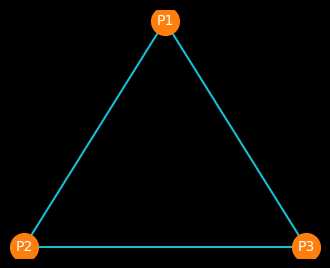

In [6]:
# friendship matrix for 3 people (all mutual friends)
A = np.array([[0, 1, 1],
              [1, 0, 1],
              [1, 1, 0]])

helpers.show(A, name="A (friendships)")
helpers.show(A.sum(axis=1), label="number of friends each (row sums)")
helpers.show(A @ A, name="A squared (two-step connections)")

# --- graphics: draw the little network by hand (mechanics only) ---
positions = {0: (0, 1), 1: (-1, -0.6), 2: (1, -0.6)}
fig, ax = plt.subplots(figsize=(4, 4))
for i in range(3):
    for j in range(i + 1, 3):
        if A[i, j] == 1:
            x0, y0 = positions[i]; x1, y1 = positions[j]
            ax.plot([x0, x1], [y0, y1], color="tab:cyan")
for node, (x, y) in positions.items():
    ax.plot(x, y, "o", color="tab:orange", markersize=20)
    ax.text(x, y, "P" + str(node + 1), ha="center", va="center")
ax.set_aspect("equal"); ax.axis("off")
plt.show()

In $A^2$, the diagonal entries equal each person's number of friends (the ways to leave and come back in two steps), and each off-diagonal entry counts the friends two people share.

## 6. Summary

- Matrix multiplication uses the **row-by-column dot product**: $(AB)_{ij} = \sum_k A_{ik}B_{kj}$.
- $A\mathbf{x}$ is both row-by-column products and a **combination of columns**.
- Order matters: $AB \ne BA$ in general.
- Powers $A^n$ of a network matrix count **$n$-step paths** — the link to Markov chains and PageRank.

Next: the other way to read $A\mathbf{x}$ — as a **function that moves every point of the
plane** (`U2-4_Transformations-1_MatrixAsMap`).